In [7]:
# Load models and split
import joblib

models = joblib.load('../data/processed/baseline_models.pkl')
train_X, val_X, train_y, val_y = joblib.load('../data/processed/train_val_split.pkl')
print(type(val_X), val_X.shape)

<class 'pandas.DataFrame'> (45957, 25)


In [8]:
# Core metrics table

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score, precision_score
import pandas as pd

results = []
for name, model in models.items():
    probs = model.predict_proba(val_X)[:, 1]
    preds = model.predict(val_X)

    results.append({
        'model': name, 
        'roc_auc': roc_auc_score(val_y, probs),
        'pr_auc': average_precision_score(val_y, probs),
        'f1': f1_score(val_y, preds), 
        'recall': recall_score(val_y, preds),
        'precision': precision_score(val_y, preds)

    })

results_df = pd.DataFrame(results)
results_df

,model,roc_auc,pr_auc,f1,recall,precision
0,Logistic Regression,0.836781,0.365145,0.382808,0.783049,0.253325
1,Random Forest,0.806923,0.280489,0.337331,0.332068,0.342764
2,LightGBM,0.837997,0.368300,0.381296,0.802024,0.250099


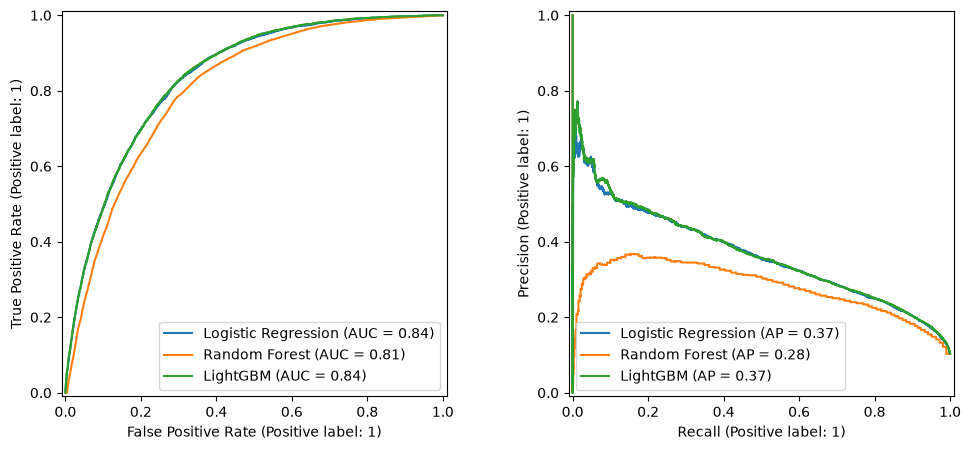

In [9]:
# ROC and Precision-Recall Curves
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for name, model in models.items():
    probs = model.predict_proba(val_X)[:, 1]
    RocCurveDisplay.from_predictions(val_y, probs, name=name, ax=ax[0])
    PrecisionRecallDisplay.from_predictions(val_y, probs, name=name, ax=ax[1])

plt.show()

In [10]:
# Cross-Validation Stability Check
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

for name, model in models.items():
    scores = cross_val_score(model, train_X, train_y, cv=cv, scoring='roc_auc')
    print(name, scores.mean(), scores.std())

Logistic Regression 0.8352406161550755 0.004093104623748479
Random Forest 0.8046353570951927 0.0028160951711766182
[LightGBM] [Info] Number of positive: 15179, number of negative: 131880
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 216
[LightGBM] [Info] Number of data points in the train set: 147059, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 15179, number of negative: 131880
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007023 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins

In [11]:
# Feature Importance 
rf_importance = pd.Series(models['Random Forest'].feature_importances_, index=train_X.columns).sort_values(ascending=False)
lgbm_importance = pd.Series(models['LightGBM'].feature_importances_, index=train_X.columns).sort_values(ascending=False)

rf_importance.head(10)
lgbm_importance.head(10)

Age                     449
BMI                     378
GenHlth                 295
Income                  224
PhysHlth                207
Sex                     173
MentHlth                164
Education               135
Stroke                  132
lifestyle_risk_score    107
dtype: int32

In [12]:
# Logistic Regression Coefficients
lr_coef = pd.Series(models['Logistic Regression'].coef_[0], index=train_X.columns).sort_values(key=abs, ascending=False)
lr_coef.head(10)

Smoker                  1.541428
lifestyle_risk_score   -1.176203
Fruits                 -1.136678
Veggies                -1.122677
PhysActivity           -1.114862
Stroke                  1.096938
HvyAlcoholConsump       0.823405
Sex                     0.799555
CholCheck               0.575704
HighBP                  0.540982
dtype: float64

In [14]:
results_df.to_csv('../data/processed/model_validation_results.csv', index=False)